In [3]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import pickle as pkl
import networkx as nx
import matplotlib.pyplot as plt

from scipy.stats import rv_histogram

import src
from src.reload import deep_reload

In [484]:
'''
Building a random graph
'''
deep_reload(src)

n = 300
k = 2

depot_likelihood = .04

rng = np.random.default_rng(26893751)

kwargs = {
    'rng': rng,
    'label': 'place',
    'x': lambda n: rng.uniform(0, 1e6, size = (n, )),
    'y': lambda n: rng.uniform(0, 1e6, size = (n, )),
    'node_functions': {
        'depot': lambda n: bool(rng.uniform() < depot_likelihood),
        'group': lambda n: rng.integers(0, 5),
    },
    'edge_functions': {
        'speed': lambda e: 65 * 1609 / 3600,
        'time': lambda e: e['distance'] / e['speed'],
    },
}

graph = src.rng.random_connected_graph(n, k, **kwargs)

kw = {
    'fields': ['time', 'distance'],
}

apg = src.rng.all_pairs_graph(graph, **kw)

depots = [k for k, v in graph._node.items() if v['depot']]
stations = [k for k, v in graph._node.items() if not v['depot']]

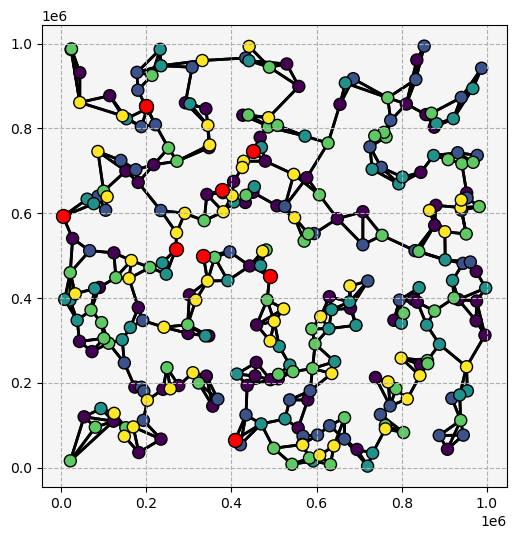

In [485]:
fig, ax = plt.subplots(figsize = (6, 6))

kw = {
    'nodes': {
        'field': 'group',
        'plot': {
            's': 75,
            'ec': 'k',
            'zorder': 1,
        },
    },
    'edges': {
        'plot':{
            'lw': 2,
            'color': 'k',
            'zorder': 0,
        },
    },
}

plots = src.figures.plot_graph(graph, ax = ax, **kw)

kw = {
    'nodes': {
        'selection': depots,
        'plot': {
            's': 100,
            'ec': 'k',
            'fc': 'red',
            'zorder': 2,
        },
    },
}

plots = src.figures.plot_graph(graph, ax = ax, **kw)

kw = {
    'facecolor': 'whitesmoke',
}

ax.set(**kw)

kw = {
    'ls': 'dashed',
}

ax.grid(**kw)

In [517]:
deep_reload(src)

partition = src.savings.depot_partition(apg, depots, objective = 'time')

rng = np.random.default_rng(108037753028)

constraints = [
    lambda graph, route: sum(
        [graph._adj[route[idx]][route[idx + 1]]['time'] for idx in range(len(route) - 1)]
    ) <= 8 * 3600
]

routes = src.savings.routes(
    apg, partition,
    objective = 'time',
    steps = 30000,
    constraints = constraints,
    rng = rng,
)

len(routes)

172

In [504]:
route = routes[60][0]
route

_adj = apg._adj

400 - np.cumsum(
    [-100e3 + _adj[route[idx]][route[idx + 1]]['distance'] for idx in range(len(route) - 1)]
) / 1e3

array([ 251.23306491,  -17.71128541, -197.58329875, -333.70299878])

In [494]:
depots

['place_42',
 'place_59',
 'place_93',
 'place_141',
 'place_177',
 'place_197',
 'place_223',
 'place_250']

In [515]:
routes

[(['place_42', 'place_1', 'place_42'], 53967.1282489662),
 (['place_42', 'place_2', 'place_42'], 42073.11226369669),
 (['place_42', 'place_3', 'place_42'], 46538.61605666643),
 (['place_42', 'place_5', 'place_42'], 49274.363416822394),
 (['place_42', 'place_9', 'place_42'], 41149.843135072304),
 (['place_42', 'place_21', 'place_42'], 47643.865983357726),
 (['place_42', 'place_22', 'place_42'], 45283.91295233153),
 (['place_42', 'place_24', 'place_42'], 43433.61717991717),
 (['place_42', 'place_38', 'place_42'], 37997.77334259925),
 (['place_42', 'place_39', 'place_42'], 50839.884194446655),
 (['place_42', 'place_45', 'place_42'], 39808.78420392403),
 (['place_42', 'place_55', 'place_42'], 52862.153610731955),
 (['place_42', 'place_60', 'place_42'], 43505.62291719334),
 (['place_42', 'place_62', 'place_42'], 44188.01117600627),
 (['place_42', 'place_68', 'place_42'], 55181.57885344957),
 (['place_42', 'place_78', 'place_42'], 38904.1159547318),
 (['place_42', 'place_84', 'place_42'], 54

In [281]:
deep_reload(src)

n = 6

partition = src.savings.random_partition(graph, n)

nx.community.modularity(graph, partition, weight = 'time', resolution = .1)

0.16170881537428689

In [282]:
[len(p) for p in partition]

[17, 17, 17, 17, 16, 16]

In [457]:
deep_reload(src)

partition = src.savings.depot_partition(apg, depots, objective = 'time')

[len(p) for p in partition.values()]

[49, 37, 14]

In [458]:
deep_reload(src)

# partition = src.savings.depot_partition(graph, depots, objective = 'time')
new_partition = src.savings.anneal_partition(
    apg, partition.copy(), objective = 'time', steps = 1000
)

[len(p) for p in new_partition.values()]

[36, 35, 29]

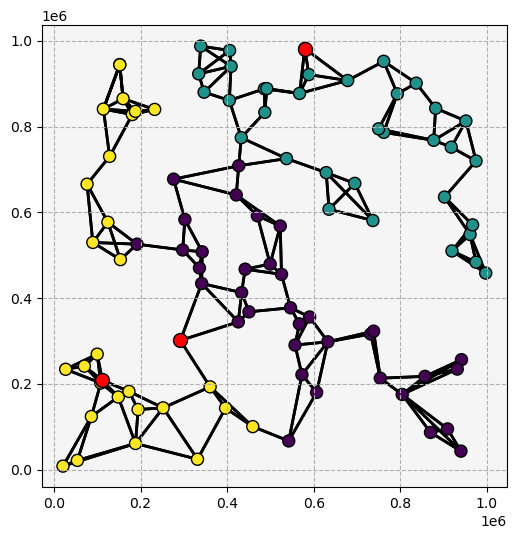

In [459]:
fig, ax = plt.subplots(figsize = (6, 6))

for idx, stations in enumerate(partition.values()):
    for station in stations:

        graph._node[station]['depot_index'] = idx

kw = {
    'nodes': {
        'field': 'depot_index',
        'plot': {
            's': 75,
            'ec': 'k',
            'zorder': 1,
        },
    },
    'edges': {
        'plot':{
            'lw': 2,
            'color': 'k',
            'zorder': 0,
        },
    },
}

plots = src.figures.plot_graph(graph, ax = ax, **kw)

kw = {
    'nodes': {
        'selection': depots,
        'plot': {
            's': 100,
            'ec': 'k',
            'fc': 'red',
            'zorder': 2,
        },
    },
}

plots = src.figures.plot_graph(graph, ax = ax, **kw)

kw = {
    'facecolor': 'whitesmoke',
}

ax.set(**kw)

kw = {
    'ls': 'dashed',
}

ax.grid(**kw)

In [482]:
deep_reload(src)

partition = src.savings.depot_partition(apg, depots, objective = 'time')

constraints = [
    lambda graph, route: len(route) <= 5,
]

routes = src.savings.routes(
    apg, partition, objective = 'time', steps = 1000, constraints = constraints
)

In [480]:
routes

[(['place_7', 'place_91', 'place_7'], 29337.536429064487),
 (['place_7', 'place_80', 'place_18', 'place_7'], 41194.91854810559),
 (['place_7', 'place_15', 'place_54', 'place_7'], 57220.86349900985),
 (['place_33', 'place_57', 'place_87', 'place_33'], 13476.65491577575),
 (['place_13', 'place_38', 'place_1', 'place_13'], 45861.162634069915),
 (['place_13', 'place_5', 'place_95', 'place_88', 'place_13'],
  76047.30930995222),
 (['place_7', 'place_75', 'place_12', 'place_86', 'place_7'],
  58106.68348311128),
 (['place_7', 'place_64', 'place_73', 'place_7'], 27497.76413128754),
 (['place_13', 'place_11', 'place_71', 'place_13'], 18361.822417948257),
 (['place_13', 'place_9', 'place_92', 'place_13'], 64844.553225061674),
 (['place_7', 'place_23', 'place_55', 'place_10', 'place_7'],
  60573.10063686324),
 (['place_33', 'place_26', 'place_94', 'place_33'], 12195.968822250186),
 (['place_13', 'place_59', 'place_89', 'place_13'], 26800.963086318443),
 (['place_7', 'place_63', 'place_85', 'plac

In [319]:
[len(p) for p in partition.values()]

[39, 53, 8]

In [275]:
a = ['place_5', 'place_6']

a.remove('place_5')

a

['place_6']

In [270]:
nx.community.modularity(
    graph, [v for v in partition.values()], weight = 'time', resolution = .1
)

0.9112136508416253

In [271]:
partition

{'place_7': ['place_7',
  'place_82',
  'place_86',
  'place_31',
  'place_51',
  'place_76',
  'place_42',
  'place_37',
  'place_64',
  'place_32',
  'place_97',
  'place_72',
  'place_10',
  'place_81',
  'place_20',
  'place_98',
  'place_63',
  'place_73',
  'place_17',
  'place_52',
  'place_75',
  'place_29',
  'place_85',
  'place_0',
  'place_53',
  'place_77',
  'place_91',
  'place_50',
  'place_18',
  'place_49',
  'place_23',
  'place_80',
  'place_36',
  'place_14',
  'place_54',
  'place_46',
  'place_78',
  'place_69',
  'place_43',
  'place_22',
  'place_45',
  'place_55',
  'place_68',
  'place_84',
  'place_70',
  'place_47',
  'place_83',
  'place_15',
  'place_79'],
 'place_13': ['place_13',
  'place_95',
  'place_71',
  'place_40',
  'place_19',
  'place_44',
  'place_11',
  'place_65',
  'place_27',
  'place_1',
  'place_5',
  'place_8',
  'place_34',
  'place_59',
  'place_4',
  'place_28',
  'place_9',
  'place_6',
  'place_56',
  'place_93',
  'place_89',
  'p

In [192]:
'''
Building a random graph
'''
deep_reload(src)

n = 10
k = 2

depot_likelihood = .04

rng = np.random.default_rng(26893751)

kwargs = {
    'rng': rng,
    'label': 'place',
    'x': lambda n: rng.uniform(0, 1e6, size = (n, )),
    'y': lambda n: rng.uniform(0, 1e6, size = (n, )),
    'node_functions': {
        'depot': lambda n: bool(rng.uniform() < depot_likelihood),
        'group': lambda n: rng.integers(0, 5),
    },
    'edge_functions': {
        'speed': lambda e: 65 * 1609 / 3600,
        'time': lambda e: e['distance'] / e['speed'],
    },
}

graph = src.rng.random_connected_graph(n, k, **kwargs)

kw = {
    'fields': ['time', 'distance'],
}

apg = src.rng.all_pairs_graph(graph, **kw)

depots = [k for k, v in graph._node.items() if v['depot']]
stations = [k for k, v in graph._node.items() if not v['depot']]

In [194]:
adjacency = nx.to_numpy_array(apg, weight = 'time')

adjacency

array([[    0.        , 21471.50314645, 26032.84492236, 29829.33336754,
        18876.46107131, 13637.11769105,  9808.26344353,  9036.21574644,
         6470.19965688, 25715.45906507],
       [21471.50314645,     0.        ,  4858.17413703,  8357.83022108,
         2595.04207515, 24447.8203937 , 31279.76658999, 20031.8794508 ,
        15001.30348957, 12369.47901967],
       [26032.84492236,  4858.17413703,     0.        ,  4166.00448559,
         7156.38385106, 19589.64625666, 32219.64363975, 24593.22122671,
        19562.64526548,  7511.30488264],
       [29829.33336754,  8357.83022108,  4166.00448559,     0.        ,
        10952.87229623, 17072.87241864, 29702.86980173, 28389.70967188,
        23359.13371065,  4994.53104461],
       [18876.46107131,  2595.04207515,  7156.38385106, 10952.87229623,
            0.        , 26746.03010772, 28684.72451484, 17436.83737565,
        12406.26141442, 14667.6887337 ],
       [13637.11769105, 24447.8203937 , 19589.64625666, 17072.87241864,
   

In [201]:
# adjacency = nx.to_numpy_array(apg, weight = 'time')

depot = 0

s, t = np.meshgrid(adjacency[:, depot].flatten(), adjacency[depot], indexing = 'ij')

savings = s + t - adjacency
# depot_index = 0

# savings = adjacency

In [238]:
nodes = list(graph.nodes)
rng = np.random.default_rng()

rng.shuffle(nodes)
partition = np.array_split(nodes, 4)

In [242]:
deep_reload(src)

n = 6

partition = src.savings.random_partition(graph, n)

nx.community.modularity(graph, partition, weight = 'time', resolution = .1)

0.11244913739787396

In [203]:
savings.sum(axis = 0)

array([     0.        , 235179.63105172, 275515.97866697, 302345.57476804,
       210119.70738361, 128266.09861084,  59326.16973195,  77621.46101189,
        80289.54458476, 256808.36962705])

In [204]:
250 * .0036

0.9

In [162]:
deep_reload(src)

savings, initial_routes, initial_route_costs = src.savings.pre_process(
    apg, stations, depots, objective = 'time',
)

_heapify_max(savings)

In [173]:
_heappop_max(savings)

(109649.29484654687, ('place_7', 'place_62', 'place_2', 'place_7'))

In [180]:
from heapq import heappop, heappush, _heappop_max, _heapify_max

heap = [1, 1.5, 2, 0]

_heapify_max(heap)
heappush(heap, 1)

In [185]:
_heappop_max(heap)

0

In [53]:
np.argwhere(np.array(depots) == 'place_7').flatten()[0]

0

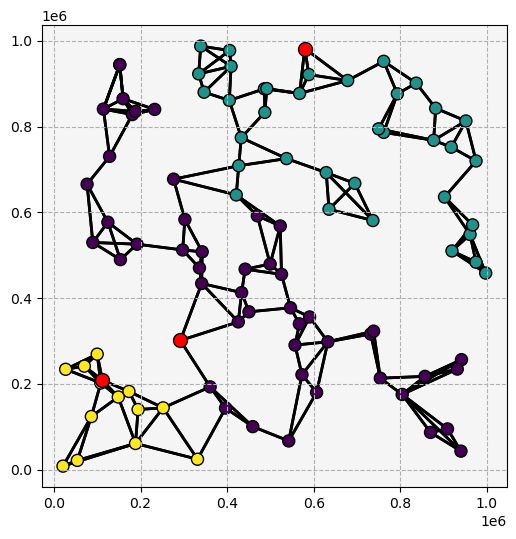

In [66]:
fig, ax = plt.subplots(figsize = (6, 6))

for route in initial_routes:

    graph._node[route[1]]['depot_index'] = np.argwhere(
        np.array(depots) == route[0]).flatten()[0] / 5

kw = {
    'nodes': {
        'selection': stations,
        'field': 'depot_index',
        'plot': {
            's': 75,
            'ec': 'k',
            'zorder': 1,
        },
    },
    'edges': {
        'plot':{
            'lw': 2,
            'color': 'k',
            'zorder': 0,
        },
    },
}

plots = src.figures.plot_graph(graph, ax = ax, **kw)

kw = {
    'nodes': {
        'selection': depots,
        'plot': {
            's': 100,
            'ec': 'k',
            'fc': 'red',
            'zorder': 2,
        },
    },
}

plots = src.figures.plot_graph(graph, ax = ax, **kw)

kw = {
    'facecolor': 'whitesmoke',
}

ax.set(**kw)

kw = {
    'ls': 'dashed',
}

ax.grid(**kw)

In [43]:
initial_routes, initial_route_costs

([['place_7', 'place_0', 'place_7'],
  ['place_13', 'place_1', 'place_13'],
  ['place_13', 'place_2', 'place_13'],
  ['place_13', 'place_3', 'place_13'],
  ['place_13', 'place_4', 'place_13'],
  ['place_13', 'place_5', 'place_13'],
  ['place_13', 'place_6', 'place_13'],
  ['place_13', 'place_8', 'place_13'],
  ['place_13', 'place_9', 'place_13'],
  ['place_7', 'place_10', 'place_7'],
  ['place_13', 'place_11', 'place_13'],
  ['place_13', 'place_12', 'place_13'],
  ['place_7', 'place_14', 'place_7'],
  ['place_7', 'place_15', 'place_7'],
  ['place_33', 'place_16', 'place_33'],
  ['place_7', 'place_17', 'place_7'],
  ['place_7', 'place_18', 'place_7'],
  ['place_13', 'place_19', 'place_13'],
  ['place_7', 'place_20', 'place_7'],
  ['place_13', 'place_21', 'place_13'],
  ['place_7', 'place_22', 'place_7'],
  ['place_7', 'place_23', 'place_7'],
  ['place_13', 'place_24', 'place_13'],
  ['place_13', 'place_25', 'place_13'],
  ['place_33', 'place_26', 'place_33'],
  ['place_13', 'place_27', 